## 1. Import Necessary Libraries

In [25]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

## 2. Import Dataset

In [2]:
claimants_data=pd.read_csv("claimants.csv")
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## 3. Data Understanding

In [3]:
claimants_data.shape

(1340, 7)

In [4]:
claimants_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [5]:
claimants_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

## 4. Data Preparation

### 4.1 Data Cleaning

In [6]:
claimants_data.dropna(inplace=True)
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [7]:
1340-1096

244

In [8]:
claimants_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

### 4.2 Seprate inputs and outputs

In [9]:
x=claimants_data.drop(labels=["CASENUM","ATTORNEY"],axis=1)
x

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [10]:
y=claimants_data["ATTORNEY"]
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

## 5. Model Building

### 5.1 Model Validation Technique - Train_Test_Split

In [11]:
 X_train, X_test, y_train, y_test=train_test_split(x,y,test_size=0.20,shuffle=True,random_state=34,)

In [12]:
X_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
478,0.0,1.0,1.0,10.0,1.318
387,1.0,1.0,0.0,55.0,0.604
47,0.0,1.0,0.0,1.0,0.000
220,1.0,1.0,1.0,7.0,0.983
152,1.0,1.0,0.0,6.0,0.075
...,...,...,...,...,...
731,0.0,1.0,0.0,30.0,4.014
817,0.0,1.0,0.0,48.0,0.390
557,0.0,1.0,0.0,30.0,0.565
386,1.0,1.0,0.0,35.0,0.860


## 6. Model Training

In [44]:
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier,VotingClassifier

In [14]:
Logistic_model=LogisticRegression()

### 6.1 - Random Forest

In [68]:
rf_classifier=RandomForestClassifier(n_estimators=75, max_depth=5,criterion='entropy')
rf_classifier.fit(X_train,y_train)

,n_estimators,75
,criterion,'entropy'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 6.2- Ada-Boost Classifier

In [81]:
Ada_Boost_classifier=AdaBoostClassifier()

In [83]:
Ada_Boost_classifier.fit(X_train,y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [16]:
Logistic_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
from sklearn.tree import DecisionTreeClassifier

In [18]:
dt_model = DecisionTreeClassifier( criterion='entropy',max_depth=5)

### 6.3 - Stacking Technique

In [97]:
from sklearn.neighbors import KNeighborsClassifier

In [100]:
logistic_classfier = LogisticRegression()
dt_classifier = DecisionTreeClassifier()
knn_classifier = KNeighborsClassifier()

voting_classifier = VotingClassifier(estimators = [("logistic_model",logistic_classfier),
("dt_model",dt_classifier),
("knn_model",knn_classifier)])

voting_classifier.fit(x,y)

y_pred = voting_classifier.predict(x)

accuracy_score(y,y_pred)

0.8394160583941606

### Grid Search CV(Cross-Validation)

In [19]:
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(estimator=dt_model,param_grid={"max_depth":[5,6,7,8,9],
                                           "criterion":['gini','entropy']})
grid_search.fit(x,y)
print("Best estimator = ",grid_search.best_estimator_)
print("Best Parameters = ",grid_search.best_params_)
print("Best Score = ",grid_search.best_score_)

Best estimator =  DecisionTreeClassifier(max_depth=5)
Best Parameters =  {'criterion': 'gini', 'max_depth': 5}
Best Score =  0.7244375259443752


In [20]:
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(estimator=dt_model,param_grid={"max_depth":[5,6,7,8,9],
                                           "criterion":['gini','entropy']})
grid_search.fit(X_train,y_train)
print("Best estimator = ",grid_search.best_estimator_)
print("Best Parameters = ",grid_search.best_params_)
print("Best Score = ",grid_search.best_score_)

Best estimator =  DecisionTreeClassifier(criterion='entropy', max_depth=5)
Best Parameters =  {'criterion': 'entropy', 'max_depth': 5}
Best Score =  0.7157532467532468


In [21]:
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(estimator=dt_model,param_grid={"max_depth":[5,6,7,8,9],
                                           "criterion":['gini','entropy']})
grid_search.fit(X_test,y_test)
print("Best estimator = ",grid_search.best_estimator_)
print("Best Parameters = ",grid_search.best_params_)
print("Best Score = ",grid_search.best_score_)

Best estimator =  DecisionTreeClassifier(criterion='entropy', max_depth=5)
Best Parameters =  {'criterion': 'entropy', 'max_depth': 5}
Best Score =  0.6909090909090909


### RANDOM FOREST

In [67]:
from sklearn.model_selection import GridSearchCV
grid_search=GridSearchCV(estimator=rf_classifier,param_grid={"max_depth":[5,6,7,8,9],
                                                             "criterion":['gini','entropy'],
                                                             "n_estimators":[50,75,100,150]})
grid_search.fit(x,y)
print("Best Parameters = ",grid_search.best_params_)
print("Best Score = ",grid_search.best_score_)

Best Parameters =  {'criterion': 'gini', 'max_depth': 5, 'n_estimators': 75}
Best Score =  0.732648401826484


In [22]:
dt_model.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

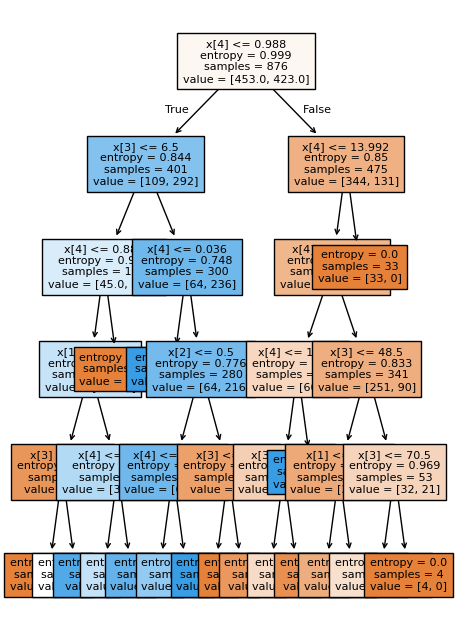

In [26]:
plt.figure(figsize=(5,8))
plot_tree(decision_tree=dt_model,fontsize=8,filled=True)
plt.show()

## 7. Model Testing

### Training Data

In [84]:
y_pred_train=rf_classifier.predict(X_train)
y_pred_train

array([0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,

### Test Data

In [85]:
y_pred_test=rf_classifier.predict(X_test)
y_pred_test

array([0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0])

## 8. Model Evaluation

In [86]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve

### 8.1 Training Data's Evaluation Metrics

In [87]:
print(confusion_matrix(y_train,y_pred_train))

[[362  91]
 [125 298]]


In [76]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.74      0.80      0.77       453
           1       0.77      0.70      0.73       423

    accuracy                           0.75       876
   macro avg       0.75      0.75      0.75       876
weighted avg       0.75      0.75      0.75       876



#### ROC Curve - Receiver Operating Characteristics
AUC - Area Under this Curve

0.7518043617804079


Text(0, 0.5, 'True Positive Rate')

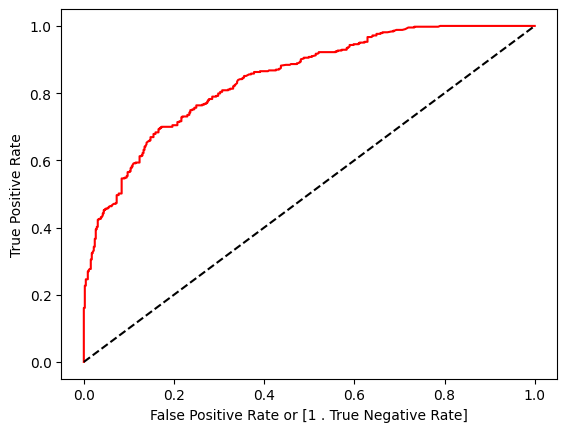

In [88]:
fpr, tpr, thresholds = roc_curve(y_train, rf_classifier.predict_proba (X_train)[:,1])

auc=roc_auc_score(y_train,y_pred_train)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label="logit model ( area = %0.2f)"%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 . True Negative Rate]')
plt.ylabel('True Positive Rate')

### 8.2 Test Data's Evaluation Metrics

In [89]:
accuracy_score(y_test,y_pred_test)

0.7227272727272728

In [90]:
print(confusion_matrix(y_test,y_pred_test))

[[95 30]
 [31 64]]


In [91]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.75      0.76      0.76       125
           1       0.68      0.67      0.68        95

    accuracy                           0.72       220
   macro avg       0.72      0.72      0.72       220
weighted avg       0.72      0.72      0.72       220



0.7518043617804079


Text(0, 0.5, 'True Positive Rate')

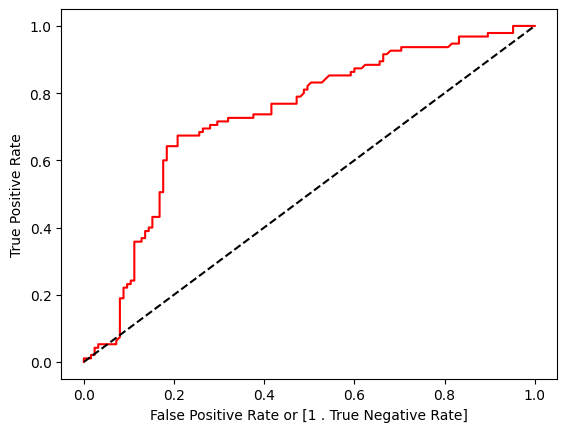

In [92]:
fpr, tpr, thresholds = roc_curve(y_test, rf_classifier.predict_proba (X_test)[:,1])

auc=roc_auc_score(y_train,y_pred_train)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label="logit model ( area = %0.2f)"%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 . True Negative Rate]')
plt.ylabel('True Positive Rate')

#### Overfitting problem
-Hey this Model got Overfitted 
#### Point to Notes
-We always expect Generalized Model

### Training Accuracy

In [93]:
accuracy_score(y_train,y_pred_train)

0.7534246575342466

In [94]:
accuracy_score(y_test,y_pred_test)

0.7227272727272728

## 9. Model Deployment

In [39]:
from pickle import dump

In [40]:
dump(Logistic_model,open("claimant.pkl","wb"))

# THE END 